# Kódová časť BP- Zeleňák

Súbor 01_Nacitanie_a_transformacia sa zameriava na prvotné načítanie poskytnutých dát, referenčných a povolených rozsahov a základnou transformaciou dát ako je transofrmácia laboratórnych parametrov a pod.
Sledujeme taktiež naplnenosť jednotlivých stĺpcov a riešime problematiku duplicít

### Použité knižnice - univerzálne

In [123]:
import pandas as pd
import numpy as np
import seaborn as sns
import os.path
from datetime import datetime
from matplotlib import pyplot as plt
from typing import Union, List, Dict, Tuple
import unidecode
import re
from openpyxl.utils import get_column_letter
from openpyxl.styles import Alignment
from collections import Counter
from itertools import combinations
from IPython.display import display

## 1. Načítanie a spojenie zdrojových dát: 
- informácia o vlne zachovaná pomocou vytvoreného stlpca "vlna"

In [124]:
from pathlib import Path
import os

vlny = {
    "1. vlna všetko 14.11.2024.xlsx": 1,
    "2. vlna všetko new 13.11.2024.xlsx": 2,
    "3. vlna všetko new 13.11.2024.xlsx": 3,
    "4.vlna do 31.5.2024 všetko new.xlsx": 4,
}

DATA_FOLDER_NAME = "VEGA_dáta z 13-11-2024"

candidates = []
if os.environ.get("VEGA_DATA_DIR"):
    candidates.append(Path(os.environ["VEGA_DATA_DIR"]))
candidates += [
    Path.cwd() / DATA_FOLDER_NAME,
    Path.cwd().parent / "DATA" / DATA_FOLDER_NAME,
]

Source_dir = next((p for p in candidates if p.is_dir()), None)
if Source_dir is None:
    raise FileNotFoundError(
        f"Priečinok s dátami '{DATA_FOLDER_NAME}' sa nenašiel.\n"
        f"Skúšané cesty: {[str(p) for p in candidates]}\n"
        f"Riešenie: nastav VEGA_DATA_DIR alebo umiestni priečinok vedľa notebooku."
    )
print(f"Source_dir = {Source_dir}")

zoznam_df = []
for file_name, vlna_cislo in vlny.items():
    cesta = Source_dir / file_name
    try:
        df_temp = pd.read_excel(cesta)
        df_temp['vlna'] = vlna_cislo
        zoznam_df.append(df_temp)
    except Exception as e:
        print(f"Nastala chyba pri načítaní súboru {cesta}: {e}")

df_comb = pd.concat(zoznam_df, ignore_index=True)
# print("\n\nCela kombinovana tabulka:")
# print(df_comb)

print("\n\nVyber 10 nahodnych zaznamov z tabulky:")
print(df_comb[['Poradie','Meno','Vek','Dátum príjmu','Dátum prepustenia','Kód príjmu','Kód prepustenia','vlna']].sample(10))


print("\n\nPocet zaznamov podla vlny:")
print(df_comb['vlna'].value_counts())
print(df_comb.shape)


Source_dir = c:\Users\DELL\Desktop\BP-Zeleňák\VEGA_dáta z 13-11-2024




Vyber 10 nahodnych zaznamov z tabulky:
      Poradie                  Meno  Vek Dátum príjmu Dátum prepustenia  \
3204      608  AXHMAMTHBTMTWCUDPHAS   70   09.05.2023        15.05.2023   
959       960  QBHMTHJXBXGYKILKLJPS   31   29.12.2020        06.01.2021   
2065      118  MFHAHTXMMAMZVURLYGTW   85   20.09.2021        29.09.2021   
1629      506  IAHMJTMUHUFUQIGUTENU   63   12.04.2021        16.04.2021   
3678     1082  WTHMHXYMHTVDMZYXKXAG   68   19.04.2022        28.04.2022   
708       709  HVHMJAHTHJZNTXYLFQCN   45   19.02.2021        19.02.2021   
3813     1217  WUHMYUUTAJCBAJPVSLAJ   51   03.03.2022        09.03.2022   
3025      429  AFHMHHAJHYQATDGACOAR   64   16.04.2023        21.04.2023   
3180      584  LAHMAAXTJXNOSZOFILXF   77   17.03.2023        24.03.2023   
2357      410  HHHMJHTTUHYLYTBWGVRZ   61   27.10.2021        15.11.2021   

      Kód príjmu  Kód prepustenia  vlna  
3204           1                1     4  
959            1                1     1  
2065   

In [125]:
#kopirovanie pre istotu ze sa neporusia povodne data
# df_w1 = df_comb[df_comb['vlna'] == 1].copy()
# df_w2 = df_comb[df_comb['vlna'] == 2].copy()
# df_w3 = df_comb[df_comb['vlna'] == 3].copy()
# df_w4 = df_comb[df_comb['vlna'] == 4].copy()

## 2. Transformácia laboratórnych výsledkov
    - extrahujeme z pôvodných 47 stĺpcov následujúce hodnoty:
        - prvú nameranú hodnotu a jej dátum vykonania
        - minimálnu nameranú hodnotu daného testu
        - strednú hodnotu (medián) nameraných hodnôt testu
        - maximálnu nameranú hodnotu testu
        - poslednú nameranú hodnotu a jej dátum vykonania

In [126]:
def transform_test_results_simplified(
    column_value: str | None,
    row_index: int,
    column_name: str,
    errors_dict: Dict[int, List[str]],
) -> Tuple[
    Union[float, float],  # prva hodnota
    Union[str, float],    # datum prvej hodnoty
    Union[float, float],  # minimum
    Union[float, float],  # median
    Union[float, float],  # maximum
    Union[float, float],  # posledna hodnota
    Union[str, float],    # datum poslednej hodnoty
]:
    EMPTY = (np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan)

    if column_value is None:
        errors_dict.setdefault(row_index, []).append(f"{column_name}: Hodnota je None")
        return EMPTY

    try:
        clean_value = str(column_value).replace("_x000D_", "").strip()
        if not clean_value:
            errors_dict.setdefault(row_index, []).append(f"{column_name}: Prázdny reťazec po čistení")
            return EMPTY

        entries = [e.strip() for e in clean_value.split(";") if e.strip()]
        if not entries:
            errors_dict.setdefault(row_index, []).append(f"{column_name}: Žiadne záznamy na parsovanie")
            return EMPTY

        parsed_entries = []
        for entry_str in entries:
            try:
                parts = entry_str.split(" | ")
                if len(parts) != 2:
                    raise ValueError(f"Nesprávny formát záznamu '{entry_str}'")

                date_time_str = parts[0].strip()
                value_str = parts[1].replace(",", ".").strip()

                date_obj = datetime.strptime(date_time_str, "%d.%m.%Y %H:%M:%S").strftime("%d.%m.%Y")
                value = float(value_str)

                parsed_entries.append({"date": date_obj, "value": value})
            except (ValueError, IndexError) as e:
                errors_dict.setdefault(row_index, []).append(
                    f"{column_name}: Chyba pri parsovaní záznamu '{entry_str}': {e}"
                )
                continue

        if not parsed_entries:
            errors_dict.setdefault(row_index, []).append(f"{column_name}: Žiadne platné záznamy po parsovaní")
            return EMPTY

        first_entry = parsed_entries[0]
        last_entry  = parsed_entries[-1]
        numeric_values = [item["value"] for item in parsed_entries]

        return (
            float(first_entry["value"]),
            first_entry["date"],
            float(np.min(numeric_values)),
            float(np.median(numeric_values)),
            float(np.max(numeric_values)),
            float(last_entry["value"]),
            last_entry["date"],
        )

    except Exception as e:
        errors_dict.setdefault(row_index, []).append(
            f"{column_name}: Neočakávaná chyba pri spracovaní '{column_value}': {e}"
        )
        return EMPTY


def create_labs_column_simplified(df: pd.DataFrame, columns_to_transform: List[str]) -> pd.DataFrame:
    errors_dict: Dict[int, List[str]] = {row_index: [] for row_index in range(len(df))}
    transformed_dfs = []

    for column in columns_to_transform:
        print(f"Spracovávam stĺpec: '{column}'")

        new_columns_df = df.apply(
            lambda row: transform_test_results_simplified(row[column], row.name, column, errors_dict),
            axis=1,
            result_type="expand",
        )

        new_columns_df.columns = [
            f"{column}_prva_hodnota",
            f"{column}_datum_prva_hodnota",
            f"{column}_minimum",
            f"{column}_median",
            f"{column}_maximum",
            f"{column}_posledna_hodnota",
            f"{column}_datum_posledna_hodnota",
        ]

        numeric_cols = [
            f"{column}_prva_hodnota",
            f"{column}_minimum",
            f"{column}_median",
            f"{column}_maximum",
            f"{column}_posledna_hodnota",
        ]
        for c in numeric_cols:
            new_columns_df[c] = pd.to_numeric(new_columns_df[c], errors="coerce")

        transformed_dfs.append(new_columns_df)

    df_with_new_cols = pd.concat([df] + transformed_dfs, axis=1)
    print("\nTransformácia dokončená.")
    return df_with_new_cols

In [127]:
columns_to_process = [
    'S-Bil-T', 'S-AST', 'S-ALT', 'S-GMT', 'S-ALP', 'S-Chol', 'S-CB', 'S-Na', 'S-K', 'S-CL',
    'S-IgG', 'S-IgA', 'S-Ig M', 'S-CRP', 'S-Alb', 'S-Bil-D', 'S-Gluk', 'S-Urea', 'S-Kreat',
    'S-KM', 'S-AMS', 'S-CK', 'S-CK-MB', 'S-LD', 'P-Laktát', 'S-FER', 'HGB', 'WBC', 'PLT',
    'Neu abs', 'Eo abs', 'Ly abs', 'PT (INR)', 'APTT-R', 'Fib', 'CD3+', 'CD4+', 'CD8+',
    'CD4+/CD8+', 'PDW', 'S-PBNP', 'S-IL6', 'CD19+', 'NK', 'S-VITD', 'NE/LY(NLR)', 'D-dimér HS'
]

df_transformed = create_labs_column_simplified(df_comb, columns_to_process)
df_transformed.head()

Spracovávam stĺpec: 'S-Bil-T'
Spracovávam stĺpec: 'S-AST'
Spracovávam stĺpec: 'S-ALT'
Spracovávam stĺpec: 'S-GMT'
Spracovávam stĺpec: 'S-ALP'
Spracovávam stĺpec: 'S-Chol'
Spracovávam stĺpec: 'S-CB'
Spracovávam stĺpec: 'S-Na'
Spracovávam stĺpec: 'S-K'
Spracovávam stĺpec: 'S-CL'
Spracovávam stĺpec: 'S-IgG'
Spracovávam stĺpec: 'S-IgA'
Spracovávam stĺpec: 'S-Ig M'
Spracovávam stĺpec: 'S-CRP'
Spracovávam stĺpec: 'S-Alb'
Spracovávam stĺpec: 'S-Bil-D'
Spracovávam stĺpec: 'S-Gluk'
Spracovávam stĺpec: 'S-Urea'
Spracovávam stĺpec: 'S-Kreat'
Spracovávam stĺpec: 'S-KM'
Spracovávam stĺpec: 'S-AMS'
Spracovávam stĺpec: 'S-CK'
Spracovávam stĺpec: 'S-CK-MB'
Spracovávam stĺpec: 'S-LD'
Spracovávam stĺpec: 'P-Laktát'
Spracovávam stĺpec: 'S-FER'
Spracovávam stĺpec: 'HGB'
Spracovávam stĺpec: 'WBC'
Spracovávam stĺpec: 'PLT'
Spracovávam stĺpec: 'Neu abs'
Spracovávam stĺpec: 'Eo abs'
Spracovávam stĺpec: 'Ly abs'
Spracovávam stĺpec: 'PT (INR)'
Spracovávam stĺpec: 'APTT-R'
Spracovávam stĺpec: 'Fib'
Spracovávam s

,Poradie,Meno,Pohlavie,Vek,Dátum príjmu,Kód príjmu,Dátum prepustenia,Kód prepustenia,HLN Dg.,Diagnózy,...,NE/LY(NLR)_maximum,NE/LY(NLR)_posledna_hodnota,NE/LY(NLR)_datum_posledna_hodnota,D-dimér HS_prva_hodnota,D-dimér HS_datum_prva_hodnota,D-dimér HS_minimum,D-dimér HS_median,D-dimér HS_maximum,D-dimér HS_posledna_hodnota,D-dimér HS_datum_posledna_hodnota
0,1,WMHAMJXUHHAEZEHBMNRM,Žena,75,23.11.2020,1,30.11.2020,1,J12.8 | Iný vírusový zápal pľúc | B,J12.8 | Iný vírusový zápal pľúc | B; _x000D_\n...,...,4.33,3.73,28.11.2020,0.725,23.11.2020,0.725,0.811,0.897,0.897,28.11.2020
1,2,WMHAMJHBMHPKDJOQLNAH,Žena,65,24.12.2020,1,06.01.2021,1,J12.8 | Iný vírusový zápal pľúc | B,J12.8 | Iný vírusový zápal pľúc | B; _x000D_\n,...,9.44,5.07,04.01.2021,1.086,24.12.2020,1.082,1.084,1.086,1.082,29.12.2020
2,3,BJHAMJHJYYFMYGYGUAMT,Žena,64,12.12.2020,1,26.12.2020,6,J12.8 | Iný vírusový zápal pľúc | B,J12.8 | Iný vírusový zápal pľúc | Z; _x000D_\n,...,48.40,48.40,22.12.2020,0.986,12.12.2020,0.694,0.986,1.034,0.694,16.12.2020
3,4,KXHAMJTAHMEVZFLVULVZ,Muž,67,16.12.2020,1,21.12.2020,1,J12.8 | Iný vírusový zápal pľúc | Z,B34.2 | Koronavírusová infekcia bez bližšieho ...,...,5.07,1.89,21.12.2020,0.301,17.12.2020,0.301,0.301,0.301,0.301,17.12.2020
4,5,TBHAMJTMUMUUJKDBNYED,Muž,82,18.12.2020,1,21.12.2020,6,J12.8 | Iný vírusový zápal pľúc | Z,J12.8 | Iný vírusový zápal pľúc | Z; _x000D_\n,...,10.58,8.90,19.12.2020,14.242,18.12.2020,14.242,14.242,14.242,14.242,18.12.2020


In [128]:
df_transformed[["S-CRP","S-CRP_prva_hodnota","S-CRP_datum_prva_hodnota","S-CRP_minimum","S-CRP_median","S-CRP_maximum","S-CRP_posledna_hodnota","S-CRP_datum_posledna_hodnota"]].head()
cols = [
    "S-CRP",
    "S-CRP_prva_hodnota",
    "S-CRP_datum_prva_hodnota",
    "S-CRP_minimum",
    "S-CRP_median",
    "S-CRP_maximum",
    "S-CRP_posledna_hodnota",
    "S-CRP_datum_posledna_hodnota"
]

df_transformed[cols].head(5).style.set_caption(
    "Ukážka transformácie laboratórneho parametra CRP"
).set_table_styles([
    {"selector": "caption",
     "props": [("font-size", "16px"),
               ("font-weight", "bold")]}
]).format(precision=2)


,S-CRP,S-CRP_prva_hodnota,S-CRP_datum_prva_hodnota,S-CRP_minimum,S-CRP_median,S-CRP_maximum,S-CRP_posledna_hodnota,S-CRP_datum_posledna_hodnota
0,"23.11.2020 11:40:00 | 111,81; _x000D_ 28.11.2020 08:59:00 | 6,50; _x000D_",111.81,23.11.2020,6.50,59.16,111.81,6.50,28.11.2020
1,"24.12.2020 20:09:00 | 46,79; _x000D_ 28.12.2020 12:22:00 | 18,57; _x000D_ 04.01.2021 06:00:00 | 3,14; _x000D_",46.79,24.12.2020,3.14,18.57,46.79,3.14,04.01.2021
2,"12.12.2020 18:09:00 | 309,14; _x000D_ 14.12.2020 08:00:00 | 289,17; _x000D_ 16.12.2020 09:37:00 | 95,82; _x000D_ 19.12.2020 08:07:00 | 97,12; _x000D_ 22.12.2020 06:00:00 | 132,24; _x000D_",309.14,12.12.2020,95.82,132.24,309.14,132.24,22.12.2020
3,"17.12.2020 06:00:00 | 29,83; _x000D_ 21.12.2020 07:19:00 | 3,39; _x000D_",29.83,17.12.2020,3.39,16.61,29.83,3.39,21.12.2020
4,"19.12.2020 09:24:00 | 258,95; _x000D_ 18.12.2020 22:19:00 | 239,37; _x000D_ 19.12.2020 08:49:00 | 235,09; _x000D_",258.95,19.12.2020,235.09,239.37,258.95,235.09,19.12.2020


## 3. Pretypovanie dátumových stĺpcov na datetime a normalizácia pohlavia 

In [129]:
# Lab dátumy
for col in df_transformed.columns:
    if col.endswith('_datum_prva_hodnota') or col.endswith('_datum_posledna_hodnota'):
        df_transformed[col] = pd.to_datetime(
            df_transformed[col], format='%d.%m.%Y', errors='coerce'
        )

# Hospitalizačné dátumy
for col in ['Dátum príjmu', 'Dátum prepustenia']:
    if col in df_transformed.columns:
        df_transformed[col] = pd.to_datetime(
            df_transformed[col], format='%d.%m.%Y', errors='coerce'
        )
# Normalizácia + kategorizácia pohlavia
df_transformed['Pohlavie'] = (
    df_transformed['Pohlavie']
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        'muž':  'Muž',  'muz':  'Muž',  'm': 'Muž',
        'žena': 'Žena', 'zena': 'Žena', 'ž': 'Žena', 'f': 'Žena',
    })
    .astype(pd.CategoricalDtype(categories=['Muž', 'Žena']))
)

print(df_transformed['Pohlavie'].value_counts(dropna=False))
print('Dtype:', df_transformed['Pohlavie'].dtype)
df_transformed.info()

Pohlavie
Muž     1926
Žena    1922
Name: count, dtype: int64
Dtype: category
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3848 entries, 0 to 3847
Columns: 399 entries, Poradie to D-dimér HS_datum_posledna_hodnota
dtypes: category(1), datetime64[ns](96), float64(235), int64(5), object(62)
memory usage: 11.7+ MB


## 4. Pokrytie laboratórnych parametrov 
V tejto časti sa zameriavame na pokrytie nameraných hodnôt laboratórnych testov. Zisťujeme počet a percento prázdnych a neprázdnych hodnôt v rámci celých stĺpcov 

In [130]:
columns_to_check = [
    'S-Bil-T', 'S-AST', 'S-ALT', 'S-GMT', 'S-ALP', 'S-Chol', 'S-CB', 'S-Na', 'S-K', 'S-CL',
    'S-IgG', 'S-IgA', 'S-Ig M', 'S-CRP', 'S-Alb', 'S-Bil-D', 'S-Gluk', 'S-Urea', 'S-Kreat',
    'S-KM', 'S-AMS', 'S-CK', 'S-CK-MB', 'S-LD', 'P-Laktát', 'S-FER', 'HGB', 'WBC', 'PLT',
    'Neu abs', 'Eo abs', 'Ly abs', 'PT (INR)', 'APTT-R', 'Fib', 'CD3+', 'CD4+', 'CD8+',
    'CD4+/CD8+', 'PDW', 'S-PBNP', 'S-IL6', 'CD19+', 'NK', 'S-VITD', 'NE/LY(NLR)', 'D-dimér HS'
]

vysledok = []

for col in columns_to_check:
    # maska pre prázdne hodnoty (vrátane prázdneho textu alebo len medzier)
    mask_prazdne = df_transformed[col].isna() | (df_transformed[col].astype(str).str.strip() == "")
    pocet_prazdnych = mask_prazdne.sum()
    pocet_neprazdnych = len(df_transformed) - pocet_prazdnych
    percento_neprazdnych = round((pocet_neprazdnych / len(df_transformed)) * 100, 2)

    vysledok.append({
        'Stĺpec': col,
        'Prázdnych hodnôt': pocet_prazdnych,
        'Neprázdnych hodnôt': pocet_neprazdnych,
        'Percento neprázdnych (%)': percento_neprazdnych
    })

df_colna = pd.DataFrame(vysledok)

print(df_colna)

        Stĺpec  Prázdnych hodnôt  Neprázdnych hodnôt  Percento neprázdnych (%)
0      S-Bil-T               115                3733                     97.01
1        S-AST                68                3780                     98.23
2        S-ALT                68                3780                     98.23
3        S-GMT                70                3778                     98.18
4        S-ALP               126                3722                     96.73
5       S-Chol              3707                 141                      3.66
6         S-CB               772                3076                     79.94
7         S-Na                30                3818                     99.22
8          S-K                30                3818                     99.22
9         S-CL                89                3759                     97.69
10       S-IgG              3645                 203                      5.28
11       S-IgA              3656                 192

### 4.1 Vizualizácia naplnenosti buniek

Horizontálny graf pokrytia všetkých 47 parametrov, doplnený o detail TOP 10 a BOTTOM 10 podľa dostupnosti dát.

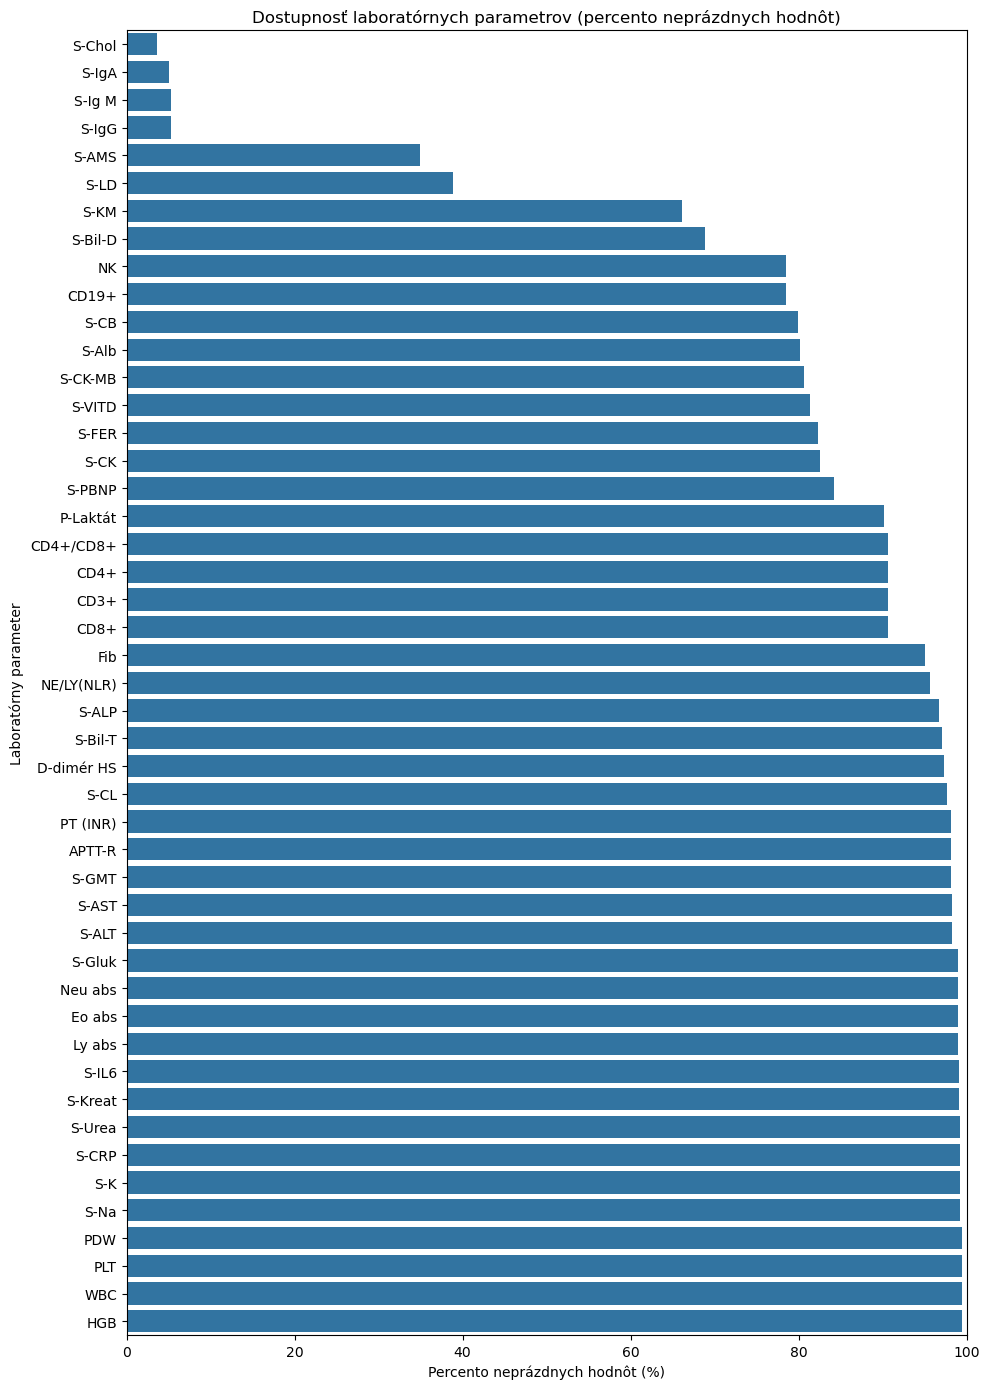

C:\Users\DELL\AppData\Local\Temp\ipykernel_9356\4176847876.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


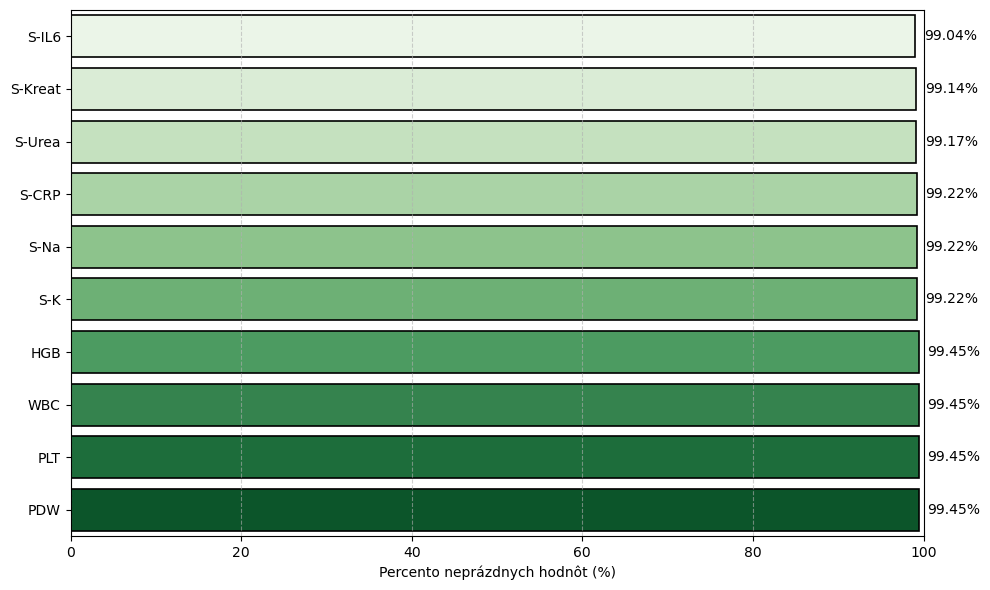

C:\Users\DELL\AppData\Local\Temp\ipykernel_9356\4176847876.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


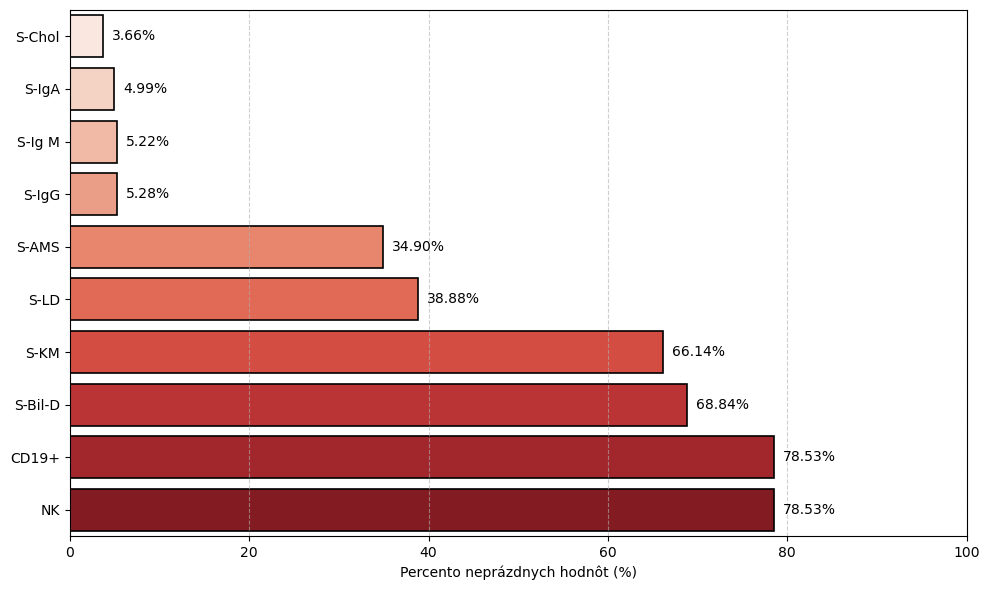

In [131]:

# zoradenie podľa dostupnosti
plot_df = df_colna.sort_values("Percento neprázdnych (%)", ascending=True).copy()

plt.figure(figsize=(10, 14))  # výška veľká, aby sa zmestilo 47 riadkov
sns.barplot(
    data=plot_df,
    x="Percento neprázdnych (%)",
    y="Stĺpec",
    orient="h"
)

plt.title("Dostupnosť laboratórnych parametrov (percento neprázdnych hodnôt)")
plt.xlabel("Percento neprázdnych hodnôt (%)")
plt.ylabel("Laboratórny parameter")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

sorted_df = df_colna.sort_values("Percento neprázdnych (%)", ascending=False)

top10 = sorted_df.head(10).sort_values("Percento neprázdnych (%)", ascending=True)
bottom10 = sorted_df.tail(10).sort_values("Percento neprázdnych (%)", ascending=True)

def barplot_with_labels(data, palette):
    plt.figure(figsize=(10, 6))

    ax = sns.barplot(
        data=data,
        x="Percento neprázdnych (%)",
        y="Stĺpec",
        orient="h",
        palette=palette,
        edgecolor="black",      
        linewidth=1.2           
    )

    ax.set_xlabel("Percento neprázdnych hodnôt (%)")
    ax.set_ylabel("")
    ax.set_xlim(0, 100)


    ax.xaxis.grid(True, linestyle="--", alpha=0.6)

    for p in ax.patches:
        width = p.get_width()
        y = p.get_y() + p.get_height() / 2
        ax.text(
            width + 1,
            y,
            f"{width:.2f}%",
            va="center",
            fontsize=10
        )

    plt.tight_layout()
    plt.show()


# TOP 10 – zelené odtiene
barplot_with_labels(
    top10,
    palette=sns.color_palette("Greens", n_colors=len(top10))
)

# BOTTOM 10 – červené odtiene
barplot_with_labels(
    bottom10,
    palette=sns.color_palette("Reds", n_colors=len(bottom10))
)



## 5. Detekcia duplicít podľa stĺpca Meno  

V procese skúmania problematiky sme narazili na zhodné páry pacientov na základe stĺpca "Meno".

In [132]:
duplicate_names = df_transformed['Meno'].value_counts()
duplicate_names = duplicate_names[duplicate_names > 1].index

df_dups = df_transformed[df_transformed['Meno'].isin(duplicate_names)].copy()

# Porovnanie v rámci rovnakeho mena
# Pre každý riadok nájdeme ostatné riadky so zhodnými údajmi
def find_matching_rows(row, df):
    subset = df[
        (df['Meno'] == row['Meno']) &
        (df['Dátum príjmu'] == row['Dátum príjmu']) &
        (df['Dátum prepustenia'] == row['Dátum prepustenia']) &
        (df['Kód prepustenia'] == row['Kód prepustenia']) &
        (df['Poradie'] != row['Poradie'])
    ]
    if subset.empty:
        return None
    else:
        return ', '.join(map(str, subset['Poradie'].tolist()))

df_dups['Zhodne_s_Poradim'] = df_dups.apply(lambda r: find_matching_rows(r, df_dups), axis=1)
df_dups['Ma_zhodu'] = df_dups['Zhodne_s_Poradim'].notna()

# Výpis-kontrola
print(f"Počet pacientov s viacerými záznamami: {df_dups['Meno'].nunique()}")
print(f"Počet pacientov s duplicitnými údajmi: {df_dups['Ma_zhodu'].sum()}")
print(df_dups[['Poradie', 'Meno', 'Dátum príjmu', 'Dátum prepustenia']])


Počet pacientov s viacerými záznamami: 52
Počet pacientov s duplicitnými údajmi: 0
      Poradie                  Meno Dátum príjmu Dátum prepustenia
216       217  WVHAHYUAJHAPHOPWMBAS   2021-02-16        2021-02-19
217       218  WVHAHYUAJHAPHOPWMBAS   2021-02-19        2021-03-01
259       260  NVHAYYTUTJMAEIXUKFXB   2020-12-02        2020-12-14
260       261  NVHAYYTUTJMAEIXUKFXB   2020-12-14        2020-12-29
274       275  BEHAUYATTTZUACLEXAYA   2020-10-21        2020-11-06
...       ...                   ...          ...               ...
3659     1063  APHMHATTHYRQUWMDLAAJ   2023-12-21        2023-12-28
3791     1195  HJHMYUJHXXBXIALJTIOT   2022-09-05        2022-09-13
3792     1196  HJHMYUJHXXBXIALJTIOT   2022-09-20        2022-09-26
3823     1227  AIHMUBJTABQMAYSHASVS   2023-12-20        2023-12-23
3824     1228  AIHMUBJTABQMAYSHASVS   2023-12-29        2024-01-04

[104 rows x 4 columns]


In [133]:
duplicate_names = df_dups['Meno'].value_counts()
duplicate_names = duplicate_names[duplicate_names > 1].index

df_dups_only = df_dups[df_dups['Meno'].isin(duplicate_names)].copy()

df_dups_every_second = df_dups_only.iloc[::2].copy()
print(df_dups_every_second[['Poradie','Meno']])

      Poradie                  Meno
216       217  WVHAHYUAJHAPHOPWMBAS
259       260  NVHAYYTUTJMAEIXUKFXB
274       275  BEHAUYATTTZUACLEXAYA
288       289  SLHAUUJATABHWRJJBCOB
374       375  RQHMHYUBJHKMWCVLQCYA
428       429  THHMAHYBMMWJYYNZVIRG
555       556  GBHMMBHJXAULDKMZFSPD
876       877  BYHMHBAHUYICHRZALIQK
985       986  HKHMTXHHUTYLKRTHCOGG
1047     1048  HUHMYXABUXXTQIEEGBSB
1242      119  ZJHAHXXJAUBWMQCZDUGK
1249      126  KOHAHXYJMHAZQADFGVQA
1339      216  MOHMHXYYYBNPINHRDODP
1352      229  ASHMHHYHXBHMTYIIMVCN
1422      299  FUHMAMXTYTNWZXEQWOVW
1553      430  VYHMMTMXHAKBPFAWNOCX
1784      661  MFHMTATXHJADJZXTQFDE
1900      777  CGHMYHHYHTSUFAOTPCKS
1911      788  JBHMYHTHMXRFAMJEVWPL
2067      120  JDHAHTYTTXSDARHUQDVZ
2092      145  PAHATAJYHTBQAGNJQGVI
2141      194  HTHMHHBXXXTJJHUKZKNK
2479      532  HEHMHHABUJCFGJLANHVG
2526      579  SRHMTTUUBXZJZJLQUAQV
2558      611  YUHMYYJHYAXABFINUYAA
2645       49  KVHAMUXUHMUQGLNYFNER
2675       79  RFHAJBUMYHLBE

### 5.1 Hĺbková analýza duplicít

Týmto krokom sa snažíme zistiť či sa nejedná o opakovanú hospitalizáciu pacienta.
Pre každú dvojicu záznamov v rámci rovnakého mena porovnávame viacero polí naraz:

- **Pohlavie a vek** — odlišné pohlavie alebo vekový rozdiel
- **Dátum príjmu, dátum prepustenia, kód prepustenia** — zhoda všetkých
  troch znamená, že ide o duplicitný zápis tej istej hospitalizácie.
- **Epikríza** — najsilnejší signál pri rozlišovaní duplicity vs. opakovanej
  hospitalizácie. Keďže ide o dlhý voľný text (tisíce znakov), porovnávame
  ho pomocou **Jaccard podobnosti** na slovných tokenoch dlhých aspoň
  3 znaky. Výsledok je číslo z intervalu [0; 1] a podľa neho zaraďujeme
  zhodu epikríz do piatich kategórií:

  | Kategória    | Jaccard       | Interpretácia                      |
  |--------------|---------------|------------------------------------|
  | totožná      | ≥ 0.95        | takmer identický text              |
  | podobná      | 0.60 – 0.94   | väčšina termínov sa zhoduje        |
  | čiastočná    | 0.30 – 0.59   | spoločné len niektoré termíny      |
  | iná          | < 0.30        | obsahovo odlišné                   |
  | neznáma      | NaN           | jedna z epikríz chýba alebo prázdna |

Z porovnania jednotlivých polí vznikne pre každý pár jednoznačná
klasifikácia:

- **`duplicita`** — rovnaké dátumy hospitalizácie a prakticky totožná
  epikríza. Ide o chybu zápisu, jeden zo záznamov je vhodný na odstránenie.
- **`opakovana_hosp`** — ten istý pacient v inej vlne (zhoda demografík,
  iné dátumy). Oba záznamy sú validné a v dátach majú zostať.
- **`manualna_kontrola`** — nejednoznačný prípad, ktorý treba pozrieť ručne
  cez `show_pair(df, poradie_A, poradie_B)`.
- **`ina_osoba`** — odlišné pohlavie alebo veľký vekový rozdiel.
  Náhodná zhoda mena, oba záznamy patria do datasetu.

In [134]:
def text_similarity_jaccard(a, b) -> float:
    if pd.isna(a) or pd.isna(b):
        return np.nan
    sa, sb = str(a).strip(), str(b).strip()
    if not sa or not sb:
        return np.nan

    tokens_a = set(re.findall(r"\w{3,}", sa.lower()))
    tokens_b = set(re.findall(r"\w{3,}", sb.lower()))

    if not tokens_a and not tokens_b:
        return 1.0
    if not tokens_a or not tokens_b:
        return 0.0
    return len(tokens_a & tokens_b) / len(tokens_a | tokens_b)


def compare_duplicate_candidates(
    df: pd.DataFrame,
    group_by: str = "Meno",
    text_field: str = "Epikríza",
    min_group_size: int = 2,
) -> pd.DataFrame:

    counts = df[group_by].value_counts()
    candidates = counts[counts >= min_group_size].index
    df_cand = df[df[group_by].isin(candidates)].copy()

    rows = []
    for name, group in df_cand.groupby(group_by, sort=False):
        records = list(group.to_dict("records"))

        for ra, rb in combinations(records, 2):
            # --- demograficke ---
            sex_match = (ra.get("Pohlavie") == rb.get("Pohlavie"))

            vek_a, vek_b = ra.get("Vek"), rb.get("Vek")
            vek_diff = abs(vek_a - vek_b) if (pd.notna(vek_a) and pd.notna(vek_b)) else np.nan

            # --- dátumy a kódy ---
            prijem_match    = (ra.get("Dátum príjmu")    == rb.get("Dátum príjmu"))
            prep_match      = (ra.get("Dátum prepustenia") == rb.get("Dátum prepustenia"))
            kod_prep_match  = (ra.get("Kód prepustenia") == rb.get("Kód prepustenia"))
            vlna_match      = (ra.get("vlna")            == rb.get("vlna"))

            # --- epikríza ---
            epi_sim = text_similarity_jaccard(ra.get(text_field), rb.get(text_field))
            if pd.isna(epi_sim):
                epi_kat = "neznama"
            elif epi_sim >= 0.95:
                epi_kat = "totozna"
            elif epi_sim >= 0.60:
                epi_kat = "podobna"
            elif epi_sim >= 0.30:
                epi_kat = "ciastocna"
            else:
                epi_kat = "ina"

            # --- klasifikácia ---
            if not sex_match:
                klas = "ina_osoba"
            elif pd.notna(vek_diff) and vek_diff > 5:
                klas = "ina_osoba"
            elif prijem_match and prep_match and epi_kat == "totozna":
                klas = "duplicita"
            elif (not prijem_match) and sex_match and (pd.isna(vek_diff) or vek_diff <= 2):
                klas = "opakovana_hosp"
            else:
                klas = "manualna_kontrola"

            rows.append({
                "meno": name,
                "poradie_A": ra.get("Poradie"),
                "poradie_B": rb.get("Poradie"),
                "vlna_A": ra.get("vlna"),
                "vlna_B": rb.get("vlna"),
                "zhoda_pohlavie": sex_match,
                "vek_A": vek_a,
                "vek_B": vek_b,
                "vek_rozdiel": vek_diff,
                "zhoda_datum_prijem": prijem_match,
                "zhoda_datum_prepustenia": prep_match,
                "zhoda_kod_prepustenia": kod_prep_match,
                "zhoda_vlna": vlna_match,
                "epikriza_similarity": round(epi_sim, 3) if pd.notna(epi_sim) else np.nan,
                "epikriza_zhoda": epi_kat,
                "klasifikacia": klas,
            })

    if not rows:
        return pd.DataFrame()

    result = pd.DataFrame(rows)

    # zoradenie: najprv duplicity, potom opakovaná hosp., potom kontrola, potom iné osoby
    klas_order = pd.CategoricalDtype(
        categories=["duplicita", "opakovana_hosp", "manualna_kontrola", "ina_osoba"],
        ordered=True,
    )
    result["klasifikacia"] = result["klasifikacia"].astype(klas_order)
    result = result.sort_values(
        ["klasifikacia", "epikriza_similarity"], ascending=[True, False]
    ).reset_index(drop=True)

    return result


def show_pair(df: pd.DataFrame, poradie_a: int, poradie_b: int, fields: list = None) -> pd.DataFrame:

    if fields is None:
        fields = [
            "Poradie", "Meno", "Pohlavie", "Vek", "vlna",
            "Dátum príjmu", "Dátum prepustenia",
            "Kód príjmu", "Kód prepustenia",
            "Stav prepustenia",
            "Diagnózy", "Epikríza",
        ]
    fields = [f for f in fields if f in df.columns]

    a = df.loc[df["Poradie"] == poradie_a].iloc[0]
    b = df.loc[df["Poradie"] == poradie_b].iloc[0]

    return pd.DataFrame({
        f"#{poradie_a}": a[fields],
        f"#{poradie_b}": b[fields],
    })


# Použitie
df_pairs = compare_duplicate_candidates(
    df_transformed,
    group_by="Meno",
    text_field="Epikríza",
)

print(f"Počet párov na kontrolu: {len(df_pairs)}")
print("\nRozdelenie podľa klasifikácie:")
print(df_pairs["klasifikacia"].value_counts())
print("\nPrehľad podľa zhody epikrízy:")
print(df_pairs["epikriza_zhoda"].value_counts())

# Podozrivé záznamy (na manuálnu kontrolu)
print("\nTOP 10 najpodobnejších záznamov")
print(df_pairs[df_pairs["klasifikacia"] == "duplicita"].head(10).to_string(index=False))


Počet párov na kontrolu: 52

Rozdelenie podľa klasifikácie:
klasifikacia
opakovana_hosp       52
duplicita             0
manualna_kontrola     0
ina_osoba             0
Name: count, dtype: int64

Prehľad podľa zhody epikrízy:
epikriza_zhoda
ina          40
ciastocna    10
podobna       2
Name: count, dtype: int64

TOP 10 najpodobnejších záznamov
Empty DataFrame
Columns: [meno, poradie_A, poradie_B, vlna_A, vlna_B, zhoda_pohlavie, vek_A, vek_B, vek_rozdiel, zhoda_datum_prijem, zhoda_datum_prepustenia, zhoda_kod_prepustenia, zhoda_vlna, epikriza_similarity, epikriza_zhoda, klasifikacia]
Index: []



### 5.2 Rozloženie opakovaných hospitalizácií podľa vĺn

Cieľom je zistiť koľko pacientov s viacerými záznamami
sa nachádza v 4. vlne – relevantné pre modelovanie.

In [135]:
def analyze_repeated_hospitalizations_by_wave(
    df: pd.DataFrame,
    patient_col: str = "Meno",
    wave_col: str = "vlna",
    target_wave: int = 4
) -> pd.DataFrame:

    # Pacienti s viac ako jedným záznamom
    repeated = (
        df.groupby(patient_col)[wave_col]
        .agg(
            pocet_zaznamov="count",
            vlny=lambda x: sorted(x.unique().tolist()),
            pocet_vln="nunique"
        )
        .reset_index()
    )
    repeated = repeated[repeated["pocet_zaznamov"] > 1].copy()

    # Príznak – je pacient v cieľovej vlne?
    repeated[f"je_vo_vlne_{target_wave}"] = repeated["vlny"].apply(
        lambda x: target_wave in x
    )

    # Rozloženie kombinácií vĺn
    repeated["vlny_str"] = repeated["vlny"].apply(
        lambda x: " + ".join(f"vlna {v}" for v in x)
    )

    # Výpisy

    print(f"PACIENTI S OPAKOVANOU HOSPITALIZÁCIOU")
    print("=" * 50)

    print(f"\nCelkový počet takýchto pacientov : {len(repeated)}")
    print(f"Z toho prítomných vo vlne {target_wave}      : "
          f"{repeated[f'je_vo_vlne_{target_wave}'].sum()}")
    print(f"Mimo vlnu {target_wave} (ostatné vlny)    : "
          f"{(~repeated[f'je_vo_vlne_{target_wave}']).sum()}")

    print(f"\n── Kombinácie vĺn ──")
    wave_combos = (
        repeated["vlny_str"]
        .value_counts()
        .reset_index()
        .rename(columns={"vlny_str": "kombinácia_vĺn", "count": "počet_pacientov"})
    )
    display(wave_combos)

    print(f"\n── Pacienti prítomní vo vlne {target_wave} ──")
    in_target = repeated[repeated[f"je_vo_vlne_{target_wave}"]].copy()
    display(
        in_target[["vlny_str", "pocet_zaznamov", "pocet_vln"]]
        .rename(columns={
            "vlny_str"      : "kombinácia_vĺn",
            "pocet_zaznamov": "počet_záznamov",
            "pocet_vln"     : "počet_rôznych_vĺn"
        })
        .sort_values("počet_rôznych_vĺn", ascending=False)
        .reset_index(drop=True)
    )

    print(f"\n Počet záznamov vo vlne {target_wave} od týchto pacientov ")
    wave4_records = df[
        (df[patient_col].isin(in_target[patient_col])) &
        (df[wave_col] == target_wave)
    ]
    print(f"Záznamy vo vlne {target_wave} od opakovaných pacientov : "
          f"{len(wave4_records)}")
    print(f"Celkový počet záznamov vo vlne {target_wave}           : "
          f"{len(df[df[wave_col] == target_wave])}")
    print(f"Podiel                                          : "
          f"{len(wave4_records) / len(df[df[wave_col] == target_wave]) * 100:.1f} %")

    return repeated


# Spustenie
repeated_hosp_df = analyze_repeated_hospitalizations_by_wave(
    df=df_transformed,
    patient_col="Meno",
    wave_col="vlna",
    target_wave=4
)

PACIENTI S OPAKOVANOU HOSPITALIZÁCIOU

Celkový počet takýchto pacientov : 52
Z toho prítomných vo vlne 4      : 27
Mimo vlnu 4 (ostatné vlny)    : 25

── Kombinácie vĺn ──


,kombinácia_vĺn,počet_pacientov
0,vlna 4,27
1,vlna 1,10
2,vlna 2,9
3,vlna 3,6



── Pacienti prítomní vo vlne 4 ──


,kombinácia_vĺn,počet_záznamov,počet_rôznych_vĺn
0,vlna 4,2,1
1,vlna 4,2,1
2,vlna 4,2,1
3,vlna 4,2,1
4,vlna 4,2,1
5,vlna 4,2,1
6,vlna 4,2,1
7,vlna 4,2,1
8,vlna 4,2,1
9,vlna 4,2,1



 Počet záznamov vo vlne 4 od týchto pacientov 
Záznamy vo vlne 4 od opakovaných pacientov : 54
Celkový počet záznamov vo vlne 4           : 1251
Podiel                                          : 4.3 %


In [136]:
# Koľko opakovaných pacientov má viac záznamov priamo vo vlne 4
wave4_only = df_transformed[df_transformed["vlna"] == 4].copy()

wave4_repeated = (
    wave4_only
    .groupby("Meno")["Poradie"]
    .count()
    .reset_index()
    .rename(columns={"Poradie": "pocet_vo_vlne4"})
)

wave4_repeated = wave4_repeated[wave4_repeated["pocet_vo_vlne4"] > 1]

print(f"Pacienti s viac ako 1 záznamom priamo vo vlne 4: {len(wave4_repeated)}")
print(f"Celkový počet takýchto záznamov: {wave4_repeated['pocet_vo_vlne4'].sum()}")
display(wave4_repeated.sort_values("pocet_vo_vlne4", ascending=False))

Pacienti s viac ako 1 záznamom priamo vo vlne 4: 27
Celkový počet takýchto záznamov: 54


,Meno,pocet_vo_vlne4
12,ADHMAYHAUBEGUWYMMMQW,2
586,KVHAMUXUHMUQGLNYFNER,2
1164,YLHMABYHJTGGLSHNRRVM,2
1135,XUHAHHBBXBLLXOJWQXXB,2
1121,XJHMMTXAAJFIOEDVDVDI,2
1036,VFHAXHUHMULESHMOONMN,2
1033,VCHMXMUMAJTLSCUPMUCM,2
1029,VAHMABYYYXZNPMUHPYDD,2
944,TIHMJXAUHUOQABRGRDDT,2
932,TBHMMHYTHTPRAFMXODHF,2


### 5.3 Uloženie do Excel formátu pre jednoduché zobrazenie

In [137]:
df_pairs.to_excel("01_duplicity_analyza.xlsx", index=False)

## 6. Referenčné hodnoty
Pre každý lab test sú v referenčnej tabuľke `rozsah_hodnot_atributov_vyplnene.xlsx`
definované dve hranice — **úzky klinický rozsah** (`ref_min` / `ref_max`)
a **širší tolerovaný rozsah** (`allowed_min` / `allowed_max`). Hodnoty sa
klasifikujú voči obidvom, pričom rozsahy môžu závisieť od pohlavia

Pre každého pacienta sa na základe tejto informácie generujú 4 status stĺpce na lab. test
(`prva_hodnota` / `posledna_hodnota` × `ref` / `allowed`) s hodnotami
**`low` / `normal` / `high`** (alebo `NaN` ak sa nedá vyhodnotiť).

Následne sa pridávajú 4 súhrnné stĺpce `Pocet_abn_*` s počtom abnormálnych hodnôt
(mimo povolenej hranice) na pacienta.


In [138]:
def parse_num_cell(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().replace(",", ".")
    m = re.search(r"[-+]?\d+(?:\.\d+)?", s)
    return float(m.group()) if m else np.nan


def parse_range_from_text(text):
    if pd.isna(text):
        return (np.nan, np.nan)

    s = str(text).strip().replace(",", ".")
    s = re.sub(r"\s+", " ", s)

    m = re.search(r"(\d+(?:\.\d+)?)\s*[-–]\s*(\d+(?:\.\d+)?)", s)
    if m:
        return float(m.group(1)), float(m.group(2))

    m = re.search(r"(?:<=|<)\s*(\d+(?:\.\d+)?)", s)
    if m:
        return np.nan, float(m.group(1))

    m = re.search(r"(?:>=|>)\s*(\d+(?:\.\d+)?)", s)
    if m:
        return float(m.group(1)), np.nan

    nums = re.findall(r"\d+(?:\.\d+)?", s)
    vals = [float(n) for n in nums]

    if len(vals) >= 2:
        return vals[0], vals[1]
    elif len(vals) == 1:
        return np.nan, vals[0]

    return (np.nan, np.nan)


def parse_bound_cell(x, bound="min"):
    if pd.isna(x):
        return np.nan

    s = str(x).strip().replace(",", ".")
    s = re.sub(r"\s+", "", s)

    m = re.match(r"^(<=|>=|<|>)?\s*([-+]?\d+(?:\.\d+)?)$", s)
    if not m:
        return np.nan

    op = m.group(1)
    val = float(m.group(2))

    if op is None:
        return val

    if op in ("<", "<="):
        return val if bound == "max" else np.nan

    if op in (">", ">="):
        return val if bound == "min" else np.nan

    return val


def normalize_test_name(name: str) -> str:
    s = str(name).strip()

    replacements = {
        "S-kreat žena": "S-Kreat žena",
        "S-kreat muž": "S-Kreat muž",
        "S-kreat": "S-Kreat",
        "SatO2 %": "SatO2 %",
    }

    return replacements.get(s, s)


def load_reference_ranges(path: str) -> pd.DataFrame:
    raw = pd.read_excel(path, header=None)

    ref = raw.iloc[3:, [0, 1, 2, 3, 4, 5]].copy()
    ref.columns = ["test_raw", "desc", "ref_min_raw", "ref_max_raw", "allowed_min_raw", "allowed_max_raw"]

    ref["test_raw"] = ref["test_raw"].astype(str).str.strip()
    ref = ref[ref["test_raw"].notna() & (ref["test_raw"] != "nan")].copy()

    ref["test_raw"] = ref["test_raw"].apply(normalize_test_name)

    ref["sex"] = np.select(
        [
            ref["test_raw"].str.contains("žena", case=False, na=False),
            ref["test_raw"].str.contains("muž", case=False, na=False),
        ],
        [
            "Žena",
            "Muž",
        ],
        default="all"
    )

    ref["test"] = (
        ref["test_raw"]
        .str.replace(" žena", "", case=False, regex=False)
        .str.replace(" muž", "", case=False, regex=False)
        .str.strip()
    )

    # referenčné hranice
    ref["ref_min"] = ref["ref_min_raw"].apply(lambda x: parse_bound_cell(x, "min"))
    ref["ref_max"] = ref["ref_max_raw"].apply(lambda x: parse_bound_cell(x, "max"))

    # povolené hranice
    ref["allowed_min"] = ref["allowed_min_raw"].apply(lambda x: parse_bound_cell(x, "min"))
    ref["allowed_max"] = ref["allowed_max_raw"].apply(lambda x: parse_bound_cell(x, "max"))

    # fallback z textového popisu LEN pre referenčný rozsah
    parsed_ranges = ref["desc"].apply(parse_range_from_text)
    ref["desc_min"] = parsed_ranges.apply(lambda x: x[0])
    ref["desc_max"] = parsed_ranges.apply(lambda x: x[1])

    ref["ref_min"] = ref["ref_min"].fillna(ref["desc_min"])
    ref["ref_max"] = ref["ref_max"].fillna(ref["desc_max"])

    ref = ref[["test", "sex", "ref_min", "ref_max", "allowed_min", "allowed_max"]].copy()

    for col in ["ref_min", "ref_max", "allowed_min", "allowed_max"]:
        ref[col] = pd.to_numeric(ref[col], errors="coerce")

    ref = ref.drop_duplicates(subset=["test", "sex"], keep="last").reset_index(drop=True)

    return ref

In [139]:
STATUS_DTYPE = pd.CategoricalDtype(categories=["low", "normal", "high"], ordered=True)

def classify_value_against_range(value, min_val=np.nan, max_val=np.nan):
    """
    Výstup:
      'low' / 'normal' / 'high' / NaN
    """
    if pd.isna(value):
        return np.nan
    if pd.notna(min_val) and value < min_val:
        return "low"
    if pd.notna(max_val) and value > max_val:
        return "high"
    if pd.notna(min_val) or pd.notna(max_val):
        return "normal"
    return np.nan


def build_status_series(values: pd.Series, lower: pd.Series, upper: pd.Series) -> pd.Series:
    
    status = pd.Series(pd.NA, index=values.index, dtype="object")

    valid = values.notna() & (lower.notna() | upper.notna())
    status.loc[valid] = "normal"
    status.loc[valid & lower.notna() & (values < lower)] = "low"
    status.loc[valid & upper.notna() & (values > upper)] = "high"

    return status.astype(STATUS_DTYPE)


def get_sex_specific_bounds(
    ref_df: pd.DataFrame,
    test: str,
    sex: pd.Series,
    min_col: str,
    max_col: str,
):

    ref_test = ref_df[ref_df["test"] == test]

    male_min   = ref_test.loc[ref_test["sex"] == "Muž",  min_col]
    male_max   = ref_test.loc[ref_test["sex"] == "Muž",  max_col]
    female_min = ref_test.loc[ref_test["sex"] == "Žena", min_col]
    female_max = ref_test.loc[ref_test["sex"] == "Žena", max_col]
    all_min    = ref_test.loc[ref_test["sex"] == "all",  min_col]
    all_max    = ref_test.loc[ref_test["sex"] == "all",  max_col]

    male_min   = male_min.iloc[0]   if len(male_min)   else np.nan
    male_max   = male_max.iloc[0]   if len(male_max)   else np.nan
    female_min = female_min.iloc[0] if len(female_min) else np.nan
    female_max = female_max.iloc[0] if len(female_max) else np.nan
    all_min    = all_min.iloc[0]    if len(all_min)    else np.nan
    all_max    = all_max.iloc[0]    if len(all_max)    else np.nan

    # NaN v 'sex' (neznáme pohlavie) automaticky padne do 'all' vetvy,
    # lebo .eq("Muž") aj .eq("Žena") vráti False pre NaN.
    lower = pd.Series(
        np.where(
            sex.eq("Muž"),  male_min,
            np.where(sex.eq("Žena"), female_min, all_min),
        ),
        index=sex.index,
        dtype="float64",
    )
    upper = pd.Series(
        np.where(
            sex.eq("Muž"),  male_max,
            np.where(sex.eq("Žena"), female_max, all_max),
        ),
        index=sex.index,
        dtype="float64",
    )

    lower = lower.where(lower.notna(), all_min)
    upper = upper.where(upper.notna(), all_max)

    return lower, upper


def add_range_status_features(df_input: pd.DataFrame, ref_df: pd.DataFrame) -> pd.DataFrame:

    df_out = df_input.copy()

    # 1) Vyčistenie referenčnej tabuľky
    ref_df = ref_df.copy()
    ref_df["test"] = ref_df["test"].astype(str).str.strip()
    ref_df["sex"]  = ref_df["sex"].fillna("all").astype(str).str.strip()

    for col in ["ref_min", "ref_max", "allowed_min", "allowed_max"]:
        ref_df[col] = pd.to_numeric(ref_df[col], errors="coerce")

    ref_df = ref_df.drop_duplicates(subset=["test", "sex"], keep="last").reset_index(drop=True)

    sex = df_out["Pohlavie"]  # už čistá kategoriálna Series

    # 2) Zoznam lab testov (z _prva_hodnota stĺpcov)
    lab_tests = sorted({
        c.replace("_prva_hodnota", "")
        for c in df_out.columns
        if c.endswith("_prva_hodnota") and "_datum_" not in c
    })

    # 3) Výpočet status stĺpcov
    new_cols = {}

    for test in lab_tests:
        for suffix in ["prva_hodnota", "posledna_hodnota"]:
            value_col = f"{test}_{suffix}"
            if value_col not in df_out.columns:
                continue

            values = pd.to_numeric(df_out[value_col], errors="coerce")

            ref_lower, ref_upper = get_sex_specific_bounds(
                ref_df=ref_df, test=test, sex=sex,
                min_col="ref_min", max_col="ref_max",
            )
            ref_status = build_status_series(values, ref_lower, ref_upper)

            allowed_lower, allowed_upper = get_sex_specific_bounds(
                ref_df=ref_df, test=test, sex=sex,
                min_col="allowed_min", max_col="allowed_max",
            )
            allowed_status = build_status_series(values, allowed_lower, allowed_upper)

            prefix = "prva" if suffix == "prva_hodnota" else "posledna"
            new_cols[f"{test}_{prefix}_ref_status"]     = ref_status
            new_cols[f"{test}_{prefix}_allowed_status"] = allowed_status

    new_cols_df = pd.DataFrame(new_cols, index=df_out.index)
    df_out = pd.concat([df_out, new_cols_df], axis=1)

    # 4) Súhrnné počty abnormalít na pacienta
    prva_ref_cols         = [c for c in df_out.columns if c.endswith("_prva_ref_status")]
    prva_allowed_cols     = [c for c in df_out.columns if c.endswith("_prva_allowed_status")]
    posledna_ref_cols     = [c for c in df_out.columns if c.endswith("_posledna_ref_status")]
    posledna_allowed_cols = [c for c in df_out.columns if c.endswith("_posledna_allowed_status")]

    df_out["Pocet_abn_prva_ref"]         = df_out[prva_ref_cols].isin(["low", "high"]).sum(axis=1)
    df_out["Pocet_abn_prva_allowed"]     = df_out[prva_allowed_cols].isin(["low", "high"]).sum(axis=1)
    df_out["Pocet_abn_posledna_ref"]     = df_out[posledna_ref_cols].isin(["low", "high"]).sum(axis=1)
    df_out["Pocet_abn_posledna_allowed"] = df_out[posledna_allowed_cols].isin(["low", "high"]).sum(axis=1)

    return df_out

### 6.1 Konkrétne extrahované hodnoty z poskytnutého Excel súboru rozsahov

In [140]:
ref_df = load_reference_ranges("rozsah_hodnot_atributov_vyplnene.xlsx")
print(ref_df.head(50))

df_ref = add_range_status_features(df_transformed, ref_df)

print(df_ref.shape)

          test   sex  ref_min  ref_max  allowed_min  allowed_max
0       APTT-R   all    0.800    1.200          0.2          8.0
1        CD19+   all    0.200    1.500          NaN          5.0
2         CD3+   all    0.600    2.000          NaN          5.0
3         CD4+   all    0.400    1.600          NaN          5.0
4    CD4+/CD8+   all    1.100    3.500          NaN          5.0
5         CD8+   all    0.070    0.310          NaN          5.0
6   D-dimér HS   all    0.000    0.500          NaN         10.0
7       Eo abs   all    0.000    0.500          NaN         10.0
8          Fib   all    1.800    4.000          NaN         10.0
9          HGB  Žena   12.000   16.000          NaN         20.0
10         HGB   Muž   12.000   17.500          NaN         22.0
11      Ly abs   all    0.800    4.000          NaN         15.0
12  NE/LY(NLR)   all    0.000    2.990          NaN         50.0
13          NK   all    0.050    0.240          NaN          5.0
14     Neu abs   all    1

In [141]:
df_ref.head()


,Poradie,Meno,Pohlavie,Vek,Dátum príjmu,Kód príjmu,Dátum prepustenia,Kód prepustenia,HLN Dg.,Diagnózy,...,S-VITD_posledna_ref_status,S-VITD_posledna_allowed_status,WBC_prva_ref_status,WBC_prva_allowed_status,WBC_posledna_ref_status,WBC_posledna_allowed_status,Pocet_abn_prva_ref,Pocet_abn_prva_allowed,Pocet_abn_posledna_ref,Pocet_abn_posledna_allowed
0,1,WMHAMJXUHHAEZEHBMNRM,Žena,75,2020-11-23,1,2020-11-30,1,J12.8 | Iný vírusový zápal pľúc | B,J12.8 | Iný vírusový zápal pľúc | B; _x000D_\n...,...,low,normal,normal,normal,high,normal,14,0,16,0
1,2,WMHAMJHBMHPKDJOQLNAH,Žena,65,2020-12-24,1,2021-01-06,1,J12.8 | Iný vírusový zápal pľúc | B,J12.8 | Iný vírusový zápal pľúc | B; _x000D_\n,...,normal,normal,normal,normal,high,normal,11,0,13,0
2,3,BJHAMJHJYYFMYGYGUAMT,Žena,64,2020-12-12,1,2020-12-26,6,J12.8 | Iný vírusový zápal pľúc | B,J12.8 | Iný vírusový zápal pľúc | Z; _x000D_\n,...,low,normal,low,normal,high,normal,27,0,26,0
3,4,KXHAMJTAHMEVZFLVULVZ,Muž,67,2020-12-16,1,2020-12-21,1,J12.8 | Iný vírusový zápal pľúc | Z,B34.2 | Koronavírusová infekcia bez bližšieho ...,...,low,normal,normal,normal,normal,normal,9,0,9,0
4,5,TBHAMJTMUMUUJKDBNYED,Muž,82,2020-12-18,1,2020-12-21,6,J12.8 | Iný vírusový zápal pľúc | Z,J12.8 | Iný vírusový zápal pľúc | Z; _x000D_\n,...,normal,normal,high,normal,high,normal,21,1,20,1


## 7. Prehľad dát a export 

In [142]:
date_cols = [col for col in df_ref.columns if col.endswith('_datum_prva_hodnota') or col.endswith('_datum_posledna_hodnota')]
df_ref[date_cols].head(5)
df_ref.dtypes.value_counts()

float64           235
category          188
datetime64[ns]     96
object             62
int64               9
category            1
Name: count, dtype: int64

In [143]:
#df_ref.loc[:, df_ref.dtypes == "object"]

### 7.1 Diagnostika

Rýchla diagnostika DataFrame pred exportom.
Vypíše súhrn (dtypes, skupiny, top NaN) a vráti detail stĺpcov.
    

In [144]:
def analyze_pred_exportom(df: pd.DataFrame) -> pd.DataFrame:
    def classify_col(col: str) -> str:
        # časové údaje
        if col.endswith(("_datum_prva_hodnota", "_datum_posledna_hodnota")):
            return "lab_datum"
        # extrahované laboratórne hodnoty
        if col.endswith(("_prva_hodnota", "_minimum", "_median",
                         "_maximum", "_posledna_hodnota")):
            return "lab_summary"
        # status voči referenčnému rozsahu
        if col.endswith("_status"):
            return "lab_ref_status"
        # vypočítané indexy (CAR_prva, NLR_prva, ...)
        if col.endswith("_prva"):
            return "index"
        # saturácie a teploty
        if col.startswith("sat_"):
            return "saturacia"
        if col.startswith("temp_") or "teplota" in col.lower():
            return "teplota"
        # raw laboratóriá zo zdroja
        if col.startswith(("S-", "P-")):
            return "lab_raw"
        # meta
        if col in {"Poradie", "Meno", "Vek", "Pohlavie", "vlna",
                   "Dátum príjmu", "Dátum prepustenia",
                   "Kód príjmu", "Kód prepustenia",
                   "Stav prepustenia", "Skupiny_Kod_prepustenia",
                   "Pocet dni hospitalizacie", "Počet dní hospitalizácie"}:
            return "meta"
        # voľný text
        if col in {"Epikríza", "Epidemiologická anamnéza",
                   "Osobná anamnéza", "Diagnózy"}:
            return "text_source"
        # klinické príznaky / komorbidity / návyky / symptómy
        if col in {"Hypertenzia", "Diabetes mellitus",
                   "Kardiovaskulárne ochorenia", "Chronické respiračné ochorenia",
                   "Pečeňové ochorenia", "Onkologické ochorenia", "Imunosupresia",
                   "Vakcinácia", "Typ vakcíny", "Počet dávok",
                   "Fajčenie", "Alkohol",
                   "kasel", "hnacka", "triaska_zimnica",
                   "zvracanie", "nechutenstvo"}:
            return "feature_klinicka"
        return "ostatne"

    info = pd.DataFrame({
        "stlpec":   df.columns,
        "dtype":    df.dtypes.astype(str).values,
        "non_null": df.notna().sum().values,
        "nan_%":    (df.isna().mean() * 100).round(2).values,
        "skupina":  [classify_col(c) for c in df.columns],
    })

    n_rows, n_cols = df.shape
    mb = df.memory_usage(deep=True).sum() / 1024**2

    print(f"DataFrame: {n_rows} riadkov × {n_cols} stĺpcov   ({mb:.1f} MB)")
    print()
    print("Dtype prehľad:")
    print(df.dtypes.astype(str).value_counts().to_string())
    print()
    print("Stĺpce podľa skupiny:")
    print(info["skupina"].value_counts().to_string())
    print()
    print("Top 10 stĺpcov s najviac NaN:")
    print(info.sort_values("nan_%", ascending=False).head(10).to_string(index=False))

    return info.sort_values(["skupina", "stlpec"]).reset_index(drop=True)



### 7.2 Export do .xlsx formátu

Export DataFrame do .xlsx s troma hárkami:
  - <sheet_name> : celé dáta (formátované dátumy, auto-fit, wrap header)
  - 'stlpce'      : detail stĺpcov (dtype, non_null, nan_%, skupina)
  - 'skupiny'     : počet stĺpcov v každej skupine
  
  Vyžaduje funkciu `analyze_pred_exportom` (vyššie).

In [145]:
def export_df_to_excel_full(
    df: pd.DataFrame,
    path: str,
    sheet_name: str = "data",
    date_width: int = 16,
    min_col_width: int = 10,
    max_col_width: int = 45,
):

    info = analyze_pred_exportom(df)  # vypíše súhrn + vráti DataFrame

    date_cols = [
        c for c in df.columns
        if ("Dátum" in c)
        or c.endswith("_datum_prva_hodnota")
        or c.endswith("_datum_posledna_hodnota")
    ]

    with pd.ExcelWriter(path, engine="openpyxl") as writer:
        # ===== Hárok 1: celé dáta =====
        df.to_excel(writer, index=False, sheet_name=sheet_name)
        ws = writer.sheets[sheet_name]

        for col_idx, col_name in enumerate(df.columns, start=1):
            letter = get_column_letter(col_idx)

            if col_name in date_cols:
                ws.column_dimensions[letter].width = date_width
                for row_idx in range(2, ws.max_row + 1):
                    cell = ws.cell(row=row_idx, column=col_idx)
                    cell.number_format = "DD.MM.YYYY"
                    cell.alignment = Alignment(horizontal="center")
            else:
                sample = df[col_name].astype(str).head(500)
                max_len = max([len(col_name)] + sample.map(len).tolist())
                ws.column_dimensions[letter].width = max(
                    min_col_width, min(max_col_width, max_len + 2)
                )

        for cell in ws[1]:
            cell.alignment = Alignment(
                wrap_text=True, horizontal="center", vertical="center"
            )

        # ===== Hárok 2: detail stĺpcov =====
        info.to_excel(writer, index=False, sheet_name="stlpce")

        # ===== Hárok 3: počty po skupinách =====
        (info["skupina"].value_counts()
              .rename_axis("skupina").reset_index(name="pocet_stlpcov")
              .to_excel(writer, index=False, sheet_name="skupiny"))

        # auto-fit pre analytické hárky
        for s in ("stlpce", "skupiny"):
            ws_a = writer.sheets[s]
            for col_idx, _ in enumerate(ws_a[1], start=1):
                letter = get_column_letter(col_idx)
                values = [str(c.value) for c in ws_a[letter] if c.value is not None]
                max_len = max((len(v) for v in values), default=10)
                ws_a.column_dimensions[letter].width = max(12, min(60, max_len + 2))

    print(f"Export hotový: {path}")
    print(f"   Hárky: '{sheet_name}', 'stlpce', 'skupiny'")


# Export do Excel formy
export_df_to_excel_full(df_ref, "01_nacitanie_transformacia.xlsx", sheet_name="df_ref")

DataFrame: 3848 riadkov × 591 stĺpcov   (84.1 MB)

Dtype prehľad:
float64           235
category          189
datetime64[ns]     96
object             62
int64               9

Stĺpce podľa skupiny:
skupina
lab_summary       235
lab_ref_status    188
lab_datum          94
ostatne            32
lab_raw            29
meta                9
text_source         4

Top 10 stĺpcov s najviac NaN:
                        stlpec    dtype  non_null  nan_%        skupina
        S-Chol_prva_ref_status category         0  100.0 lab_ref_status
         S-IgA_prva_ref_status category         0  100.0 lab_ref_status
S-Ig M_posledna_allowed_status category         0  100.0 lab_ref_status
     S-IgA_prva_allowed_status category         0  100.0 lab_ref_status
     S-IgA_posledna_ref_status category         0  100.0 lab_ref_status
    S-Ig M_posledna_ref_status category         0  100.0 lab_ref_status
    S-Ig M_prva_allowed_status category         0  100.0 lab_ref_status
        S-Ig M_prva_ref_status c

### 7.3 Export pre nadväzujúci notebook

In [146]:
# Uloženie predspracovaného DataFrame `df_ref` pre notebook 02_Extrakcia_zo_stlpcov
df_ref.to_parquet('01_nacitanie_transformacia.parquet')
print('Uložené: 01_nacitanie_transformacia.parquet')
print(f'Tvar: {df_ref.shape}')

Uložené: 01_nacitanie_transformacia.parquet
Tvar: (3848, 591)
